# Домашнее задание 2. RAG, векторная база и память агента

Корпус и вопросы — из README (раздел «Домашнее задание 2», шаг 1): 30 обзорных страниц Wikipedia про 2026 год, переиспользованных из первой домашки, плюс 10 вопросов без ответа. Код шагов 2–4 адаптирован из `seminar02_skeleton_full.ipynb` под этот корпус.

In [1]:
%pip install -q requests pydantic python-dotenv pandas matplotlib numpy pymilvus pypdf

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, re, sys, json, time, hashlib, threading
from pathlib import Path
from dataclasses import dataclass, field
from concurrent.futures import ThreadPoolExecutor
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from pymilvus import MilvusClient

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком"

CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
EMBED_URL = "https://openrouter.ai/api/v1/embeddings"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}", "X-Title": "agents-course-homework02"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
EMBED_MODEL, DIM = "openai/text-embedding-3-small", 512
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
DATA = Path("data")
Path("img").mkdir(exist_ok=True)


@dataclass
class Ledger:
    calls: list = field(default_factory=list)
    local: threading.local = field(default_factory=threading.local)

    def add(self, tag, model, usage, seconds=0.0):
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": usage.get("prompt_tokens", 0),
                           "completion": usage.get("completion_tokens", 0), "cost": cost, "seconds": round(seconds, 2)})
        self.local.spent = self.mine + cost
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    @property
    def mine(self):
        return getattr(self.local, "spent", 0.0)

    def table(self):
        frame = pd.DataFrame(self.calls, columns=["tag", "model", "prompt", "completion", "cost", "seconds"])
        return frame.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                                      completion=("completion", "sum"), cost=("cost", "sum")).round(5)


ledger = Ledger()


def post_with_retry(url, body, attempts=5):
    problem = "нет ответа"
    for attempt in range(attempts):
        try:
            r = requests.post(url, json=body, headers=HEADERS, timeout=120)
            if r.status_code == 200:
                return r.json()
            problem = f"HTTP {r.status_code}: {r.text[:200]}"
            if r.status_code not in (429, 500, 502, 503, 504):
                break
        except requests.RequestException as e:
            problem = type(e).__name__
        time.sleep(2.0 * (attempt + 1))
    raise RuntimeError(problem)


def chat(messages, model, tools=None, tag="chat"):
    body = {"model": model, "messages": messages, "temperature": 0, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
    started = time.perf_counter()
    data = post_with_retry(CHAT_URL, body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]


def load_jsonl(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

## Шаг 1. Корпус и вопросы (напоминание)

Корпус — `data/corpus_2026.jsonl`, собран `fetch_corpus.py`: 30 обзорных страниц Wikipedia про 2026 год (те же темы, что в первой домашке). Вопросы — `data/fresh_2026.jsonl`, 146 из 148 вопросов первой домашки, у каждого есть поле `evidence` — цитата, по которой размечен верный кусок. Отдельно — `data/unanswerable.jsonl`, 10 вопросов на ту же тему, ответа на которые в корпусе нет (проверено построчным поиском ключевых фраз по всему тексту).

In [3]:
corpus = load_jsonl("corpus_2026.jsonl")
tasks = load_jsonl("fresh_2026.jsonl")
unanswerable = load_jsonl("unanswerable.jsonl")
len(corpus), sum(len(p["text"]) for p in corpus), len(tasks), len(unanswerable), tasks[0]

(30,
 891391,
 146,
 10,
 {'id': 'fresh-0',
  'source': 'fresh',
  'question': 'On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics?',
  'answer': '15 March',
  'evidence': '15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest over Russian athletes being allowed to compete under the Russian flag after the lifting of sanctions imposed over the Russian invasion in 2022.',
  'page': '2026 in Ukraine',
  'url': 'https://en.wikipedia.org/wiki/2026_in_Ukraine',
  'agent_ok': False})

## Шаг 2. Нарезка, эмбеддинги, Milvus, качество поиска

### Две нарезки

Страница устроена как список датированных событий: одна строка — одно событие, заголовок раздела — месяц. Наивная нарезка режет по 400 символов, не глядя на границы, и может разорвать событие пополам. Осмысленная нарезка режет по строкам: **граница куска проходит на переносе строки, потому что на странице каждая строка уже является одним законченным фактом (одно событие = одна строка), а заголовок-месяц едет с ней как метаданные `section`.**

In [4]:
def chunk_lines(page):
    chunks, section = [], ""
    for line in page["text"].splitlines():
        line = " ".join(line.split())
        if line.startswith("="):
            section = line.strip("= ")
        elif len(line) > 40:
            chunks.append({"page": page["page"], "section": section, "url": page["url"], "text": line})
    return chunks


def chunk_chars(page, size=400):
    text = " ".join(page["text"].split())
    return [{"page": page["page"], "section": "", "url": page["url"], "text": text[i:i + size]} for i in range(0, len(text), size)]


line_chunks = [c for p in corpus for c in chunk_lines(p)]
char_chunks = [c for p in corpus for c in chunk_chars(p)]
len(line_chunks), len(char_chunks)

(6060, 2234)

### Эмбеддинги с кэшем на диске

Кэш — файл `emb_cache.npz`: ключ — sha1 текста, значение — вектор. Повторный запуск ноутбука не пересчитывает то, что уже посчитано.

In [5]:
EMB = {}
CACHE_PATH = Path("emb_cache.npz")

def load_cache():
    if CACHE_PATH.exists():
        z = np.load(CACHE_PATH)
        EMB.update({str(k): v.astype(np.float32) for k, v in zip(z["keys"], z["vectors"])})
    return len(EMB)

def save_cache():
    np.savez_compressed(CACHE_PATH, keys=np.array(list(EMB)), vectors=np.stack(list(EMB.values())).astype(np.float16))

def embed_batch(texts):
    started = time.perf_counter()
    data = post_with_retry(EMBED_URL, {"model": EMBED_MODEL, "input": texts, "dimensions": DIM})
    ledger.add("embed", EMBED_MODEL, data.get("usage") or {}, time.perf_counter() - started)
    return [row["embedding"] for row in data["data"]]

def key_of(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

def embed_cached(texts):
    missing = list(dict.fromkeys(t for t in texts if key_of(t) not in EMB))
    for i in range(0, len(missing), 64):
        batch = missing[i:i + 64]
        for text, vector in zip(batch, embed_batch(batch)):
            EMB[key_of(text)] = np.asarray(vector, dtype=np.float32)
    vectors = np.stack([EMB[key_of(t)] for t in texts])
    return vectors / np.linalg.norm(vectors, axis=1, keepdims=True)

load_cache()

8415

In [6]:
def emb_text(chunk):
    return f"{chunk['page']}: {chunk['text']}"

line_vecs = embed_cached([emb_text(c) for c in line_chunks])
char_vecs = embed_cached([c["text"] for c in char_chunks])
q_vecs = embed_cached([t["question"] for t in tasks])
unans_vecs = embed_cached([t["question"] for t in unanswerable])
save_cache()
line_vecs.shape, char_vecs.shape, q_vecs.shape, unans_vecs.shape, round(ledger.total, 4)

((6060, 512), (2234, 512), (146, 512), (10, 512), 0)

### Индекс в Milvus

Коллекция хранит вектор и метаданные (`page`, `section`, `url`, `text`) рядом, поэтому по ним можно фильтровать без похода за исходником. Заводим обе нарезки отдельными коллекциями, чтобы сравнить их качество поиска.

In [7]:
MILVUS_URI = os.getenv("MILVUS_URI", "http://localhost:19530")
client = MilvusClient(uri=MILVUS_URI, token=os.getenv("MILVUS_TOKEN", ""))
client.get_server_version(), client.list_collections()

('2.6.24', ['lines', 'chars'])

In [8]:
def index_to_milvus(name, chunks, vectors):
    if client.has_collection(name):
        client.drop_collection(name)
    client.create_collection(name, dimension=vectors.shape[1], metric_type="COSINE")
    rows = [{"id": i, "vector": v.tolist(), **c} for i, (c, v) in enumerate(zip(chunks, vectors))]
    for i in range(0, len(rows), 1000):
        client.insert(name, rows[i:i + 1000])
    client.flush(name)
    return client.get_collection_stats(name)


def search_milvus(name, query, k=5, flt=""):
    vector = embed_cached([query])[0].tolist()
    hits = client.search(name, data=[vector], limit=k, filter=flt, output_fields=["page", "section", "url", "text"])[0]
    return [{**h["entity"], "id": h["id"], "score": round(h["distance"], 4)} for h in hits]


index_to_milvus("lines", line_chunks, line_vecs), index_to_milvus("chars", char_chunks, char_vecs)

({'row_count': 6060}, {'row_count': 2234})

Фильтр по документу (`page`) — демонстрация: та же коллекция `lines`, вопрос про землетрясения, но только по странице «2026 in Japan» (в корпусе есть события с этой темой на нескольких страницах, фильтр сужает выдачу до одной).

In [9]:
pd.DataFrame(search_milvus("lines", "earthquake magnitude", 5, 'page == "2026 in Japan"'))[["score", "page", "section", "text"]]

,score,page,section,text
0,0.4603,2026 in Japan,April,April 20 – A magnitude 7.7 earthquake hits off...
1,0.4578,2026 in Japan,May,May 15 – A magnitude 6.3 earthquake strikes of...
2,0.4549,2026 in Japan,May,A magnitude 5.9 earthquake strikes southern Am...
3,0.4351,2026 in Japan,April,A magnitude 5.0 earthquake hits southern Tochi...
4,0.4288,2026 in Japan,April,April 27 – A magnitude 6.1 earthquake strikes ...


### Качество поиска: recall@k

Верным считаем кусок с той же страницы, где есть эталонный ответ и не меньше половины слов цитаты `evidence` — так наивная нарезка честно получает штраф за разорванные пополам факты. recall@k считаем прямо по выдаче Milvus, одним пакетным запросом на всю выборку вопросов.

,по строкам,по 400 символов
1,0.842,0.521
3,0.945,0.719
5,0.952,0.788
10,0.952,0.829


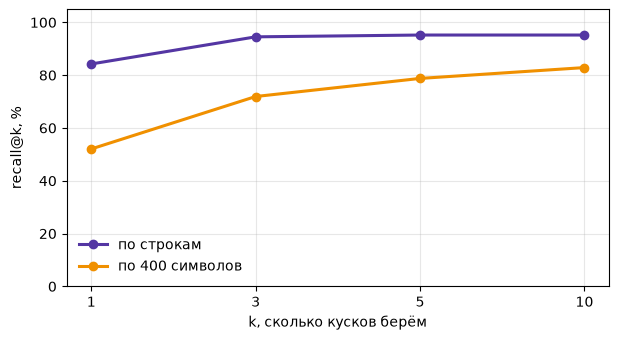

In [10]:
NUMBERS = {word: str(n) for n, word in enumerate("zero one two three four five six seven eight nine ten eleven twelve".split())}

def norm(text):
    words = re.sub(r"\b(a|an|the)\b|[^\w\s]", " ", str(text).lower()).split()
    return " ".join(NUMBERS.get(w, w) for w in words)

def is_gold(chunk, task):
    if chunk["page"] != task["page"]:
        return False
    text, words = norm(chunk["text"]), norm(task["evidence"]).split()
    return norm(task["answer"]) in text and sum(w in text for w in words) >= 0.5 * len(words)

def recall_curve_milvus(name, chunks, vectors, ks=(1, 3, 5, 10)):
    hits = client.search(name, data=vectors.tolist(), limit=max(ks), output_fields=["page", "section", "url", "text"])
    ranked = [[h["id"] for h in row] for row in hits]
    id_to_chunk = {i: c for i, c in enumerate(chunks)}
    return {k: float(np.mean([any(is_gold(id_to_chunk[i], t) for i in r[:k]) for r, t in zip(ranked, tasks)])) for k in ks}

curves = {"по строкам": recall_curve_milvus("lines", line_chunks, q_vecs),
          "по 400 символов": recall_curve_milvus("chars", char_chunks, q_vecs)}
fig, ax = plt.subplots(figsize=(7, 3.6))
for (name, curve), color in zip(curves.items(), [COLORS["violet"], COLORS["amber"]]):
    ax.plot([str(k) for k in curve], [v * 100 for v in curve.values()], marker="o", lw=2.2, color=color, label=name)
ax.set_xlabel("k, сколько кусков берём"); ax.set_ylabel("recall@k, %"); ax.set_ylim(0, 105); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/recall.png", dpi=150, bbox_inches="tight")
pd.DataFrame(curves).round(3)

Recall@5 (0.952) у нарезки по строкам равен recall@10 (0.952) — прирост от k=5 до k=10 нулевой, а у нарезки по символам recall всё ещё растёт (0.788 → 0.829), но она и так заметно хуже строчной на любом k. **Для шага 3 берём k=5 на нарезке по строкам**: качество на плато, а контекст короче и дешевле, чем при k=10.

In [11]:
for name, curve in curves.items():
    print(name, {k: round(v, 3) for k, v in curve.items()})

по строкам {1: 0.842, 3: 0.945, 5: 0.952, 10: 0.952}
по 400 символов {1: 0.521, 3: 0.719, 5: 0.788, 10: 0.829}


### Гибрид: вектор + слова + RRF

Поиск по словам (BM25-подобный, через IDF) ловит точные имена и числа, которые эмбеддинг иногда смазывает. RRF сливает два ранжирования по позиции, без нормировки скоров разной природы.

In [12]:
def tokens(text):
    return re.findall(r"\w+", text.lower())

def build_keyword_index(texts):
    docs = [set(tokens(text)) for text in texts]
    df = {}
    for d in docs:
        for w in d:
            df[w] = df.get(w, 0) + 1
    return docs, {w: np.log(len(docs) / n) for w, n in df.items()}

def keyword_search(query, docs, idf, k=20):
    q = set(tokens(query))
    scores = np.array([sum(idf.get(w, 0.0) for w in q & d) for d in docs])
    return [int(i) for i in np.argsort(-scores)[:k]]

def search_numpy(query_vec, vectors, k=5):
    sims = vectors @ query_vec
    top = np.argsort(-sims)[:k]
    return [(int(i), float(sims[i])) for i in top]

def rrf(rankings, k=5, K=60):
    scores = {}
    for ranking in rankings:
        for rank, idx in enumerate(ranking):
            scores[idx] = scores.get(idx, 0.0) + 1 / (K + rank + 1)
    return sorted(scores, key=scores.get, reverse=True)[:k]

def recall_of(rankings, chunks, k=5):
    return float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(rankings, tasks)]))

rows = []
for cut, chunks, vectors, texts in [("по 400 символов", char_chunks, char_vecs, [c["text"] for c in char_chunks]),
                                    ("по строкам", line_chunks, line_vecs, [emb_text(c) for c in line_chunks])]:
    docs, idf = build_keyword_index(texts)
    by_vector = [[i for i, _ in search_numpy(q, vectors, 20)] for q in q_vecs]
    by_words = [keyword_search(t["question"], docs, idf, 20) for t in tasks]
    by_hybrid = [rrf([v, w], 20) for v, w in zip(by_vector, by_words)]
    rows += [{"нарезка": cut, "поиск": name, "recall@1": recall_of(r, chunks, 1), "recall@5": recall_of(r, chunks, 5)}
             for name, r in [("только вектор", by_vector), ("только слова", by_words), ("гибрид RRF", by_hybrid)]]
hybrid = pd.DataFrame(rows).round(2)
hybrid

,нарезка,поиск,recall@1,recall@5
0,по 400 символов,только вектор,0.52,0.79
1,по 400 символов,только слова,0.76,0.90
2,по 400 символов,гибрид RRF,0.70,0.90
3,по строкам,только вектор,0.86,0.98
4,по строкам,только слова,0.89,0.98
5,по строкам,гибрид RRF,0.88,1.00


### Деньги, потраченные в этом ноутбуке на шаг 2 (эмбеддинги)

In [13]:
ledger.table(), round(ledger.total, 4)

(                              calls  prompt  completion  cost
 tag   model                                                  
 embed text-embedding-3-small      1       3           0   0.0,
 0.0)